In [ ]:
# %pip install -r ../requirements.txt

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached notebook-7.6.0-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab-4.6.0-py3-none-any.whl.metadata (16 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
  Using cached httpx-0.28.1-py3-none-any.w

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

DATABASE_URL = "postgresql://tripplancaster@localhost:5432/dataco_supply_chain"
engine = create_engine(DATABASE_URL)

query = """
SELECT
    f.days_for_shipping_real,
    f.days_for_shipment_scheduled,
    f.delivery_status,
    f.late_delivery_risk,
    o.shipping_mode,
    o.market,
    o.order_region,
    o.order_date_dateorders,
    oi.order_item_quantity,
    oi.order_item_total,
    p.product_price,
    p.category_id
FROM fulfillment f
INNER JOIN orders o ON f.order_id = o.order_id
INNER JOIN order_items oi ON o.order_id = oi.order_id
INNER JOIN products p ON oi.product_card_id = p.product_card_id;
"""

print("Querying database and pulling features into Python...")
df = pd.read_sql_query(query, con=engine)
print(f"Successfully loaded DataFrame with {df.shape[0]} rows and {df.shape[1]} columns.")

df.head()

Querying database and pulling features into Python...
Successfully loaded DataFrame with 180519 rows and 12 columns.


,days_for_shipping_real,days_for_shipment_scheduled,delivery_status,late_delivery_risk,shipping_mode,market,order_region,order_date_dateorders,order_item_quantity,order_item_total,product_price,category_id
0,2,4,Advance shipping,0,Standard Class,LATAM,Central America,2015-01-01 00:00:00,1,239.98,299.98,43
1,3,4,Advance shipping,0,Standard Class,LATAM,South America,2015-01-01 00:21:00,1,193.99,199.99,48
2,3,4,Advance shipping,0,Standard Class,LATAM,South America,2015-01-01 00:21:00,1,107.89,129.99,18
3,3,4,Advance shipping,0,Standard Class,LATAM,South America,2015-01-01 00:21:00,5,227.50,50.00,24
4,5,4,Late delivery,1,Standard Class,LATAM,South America,2015-01-01 01:03:00,2,40.98,24.99,40


In [6]:
df['order_date_dateorders'] = pd.to_datetime(df['order_date_dateorders'])

df['order_year'] = df['order_date_dateorders'].dt.year
df['order_month'] = df['order_date_dateorders'].dt.month
df['order_day'] = df['order_date_dateorders'].dt.day
df['order_hour'] = df['order_date_dateorders'].dt.hour
df['order_day_of_week'] = df['order_date_dateorders'].dt.dayofweek

df['expected_delivery_buffer'] = df['days_for_shipment_scheduled'] - df['days_for_shipping_real']

df_cleaned = df.drop(columns=['order_date_dateorders'])

print("Feature Engineering complete. Dimensions:", df_cleaned.shape)
df_cleaned.head()

Feature Engineering complete. Dimensions: (180519, 17)


,days_for_shipping_real,days_for_shipment_scheduled,delivery_status,late_delivery_risk,shipping_mode,market,order_region,order_item_quantity,order_item_total,product_price,category_id,order_year,order_month,order_day,order_hour,order_day_of_week,expected_delivery_buffer
0,2,4,Advance shipping,0,Standard Class,LATAM,Central America,1,239.98,299.98,43,2015,1,1,0,3,2
1,3,4,Advance shipping,0,Standard Class,LATAM,South America,1,193.99,199.99,48,2015,1,1,0,3,1
2,3,4,Advance shipping,0,Standard Class,LATAM,South America,1,107.89,129.99,18,2015,1,1,0,3,1
3,3,4,Advance shipping,0,Standard Class,LATAM,South America,5,227.50,50.00,24,2015,1,1,0,3,1
4,5,4,Late delivery,1,Standard Class,LATAM,South America,2,40.98,24.99,40,2015,1,1,1,3,-1


/var/folders/kl/0msp88353r3_cbsnqqb3c6d00000gn/T/ipykernel_71042/225106550.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='late_delivery_risk', data=df_cleaned, palette='viridis')


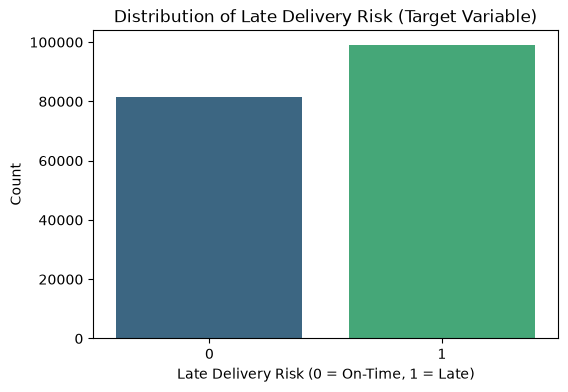

late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='late_delivery_risk', data=df_cleaned, palette='viridis')
plt.title('Distribution of Late Delivery Risk (Target Variable)')
plt.xlabel('Late Delivery Risk (0 = On-Time, 1 = Late)')
plt.ylabel('Count')
plt.show()

print(df_cleaned['late_delivery_risk'].value_counts(normalize=True) * 100)

In [9]:
categorical_cols = ['shipping_mode', 'market', 'order_region']

df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True, dtype=int)

df_encoded = df_encoded.drop(columns=['delivery_status'])

print("Final Model Training Matrix Ready.")
print(f"New Dimensions: {df_encoded.shape[0]} rows and {df_encoded.shape[1]} features.")
df_encoded.head()

Final Model Training Matrix Ready.
New Dimensions: 180519 rows and 42 features.


,days_for_shipping_real,days_for_shipment_scheduled,late_delivery_risk,order_item_quantity,order_item_total,product_price,category_id,order_year,order_month,order_day,...,order_region_South Asia,order_region_South of USA,order_region_Southeast Asia,order_region_Southern Africa,order_region_Southern Europe,order_region_US Center,order_region_West Africa,order_region_West Asia,order_region_West of USA,order_region_Western Europe
0,2,4,0,1,239.98,299.98,43,2015,1,1,...,0,0,0,0,0,0,0,0,0,0
1,3,4,0,1,193.99,199.99,48,2015,1,1,...,0,0,0,0,0,0,0,0,0,0
2,3,4,0,1,107.89,129.99,18,2015,1,1,...,0,0,0,0,0,0,0,0,0,0
3,3,4,0,5,227.50,50.00,24,2015,1,1,...,0,0,0,0,0,0,0,0,0,0
4,5,4,1,2,40.98,24.99,40,2015,1,1,...,0,0,0,0,0,0,0,0,0,0


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

X = df_encoded.drop(columns=['late_delivery_risk'])
y = df_encoded['late_delivery_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training shapes: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Testing shapes:  X_test: {X_test.shape}, y_test: {y_test.shape}\n")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  
    random_state=42,
    n_jobs=-1      
)

print("Training the Random Forest Model...")
model.fit(X_train, y_train)
print("Training complete!")

y_pred = model.predict(X_test)

print("\n===== Model Performance Metrics =====")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Training shapes: X_train: (144415, 41), y_train: (144415,)
Testing shapes:  X_test: (36104, 41), y_test: (36104,)

Training the Random Forest Model...
Training complete!

===== Model Performance Metrics =====
Accuracy Score: 97.57%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     16308
           1       0.96      1.00      0.98     19796

    accuracy                           0.98     36104
   macro avg       0.98      0.97      0.98     36104
weighted avg       0.98      0.98      0.98     36104



/var/folders/kl/0msp88353r3_cbsnqqb3c6d00000gn/T/ipykernel_71042/632706171.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='mako')


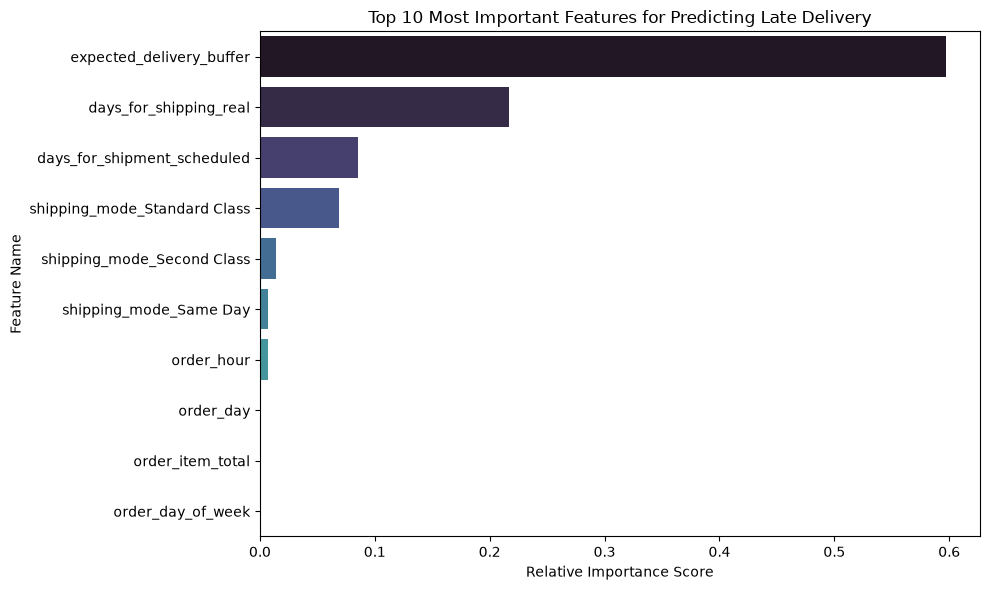

In [12]:
importances = model.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='mako')
plt.title('Top 10 Most Important Features for Predicting Late Delivery')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [14]:
leakage_features = ['expected_delivery_buffer', 'days_for_shipping_real']
X_predictive = X.drop(columns=leakage_features)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_predictive, y, test_size=0.2, random_state=42, stratify=y
)

predictive_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=1
)

predictive_model.fit(X_train_p, y_train_p)

y_pred_p = predictive_model.predict(X_test_p)
print(f"True Predictive Model Accuracy: {accuracy_score(y_test_p, y_pred_p) * 100:.2f}%")


True Predictive Model Accuracy: 71.83%


/var/folders/kl/0msp88353r3_cbsnqqb3c6d00000gn/T/ipykernel_71042/822982874.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_p[indices_p], y=feature_names_p[indices_p], palette='magma')


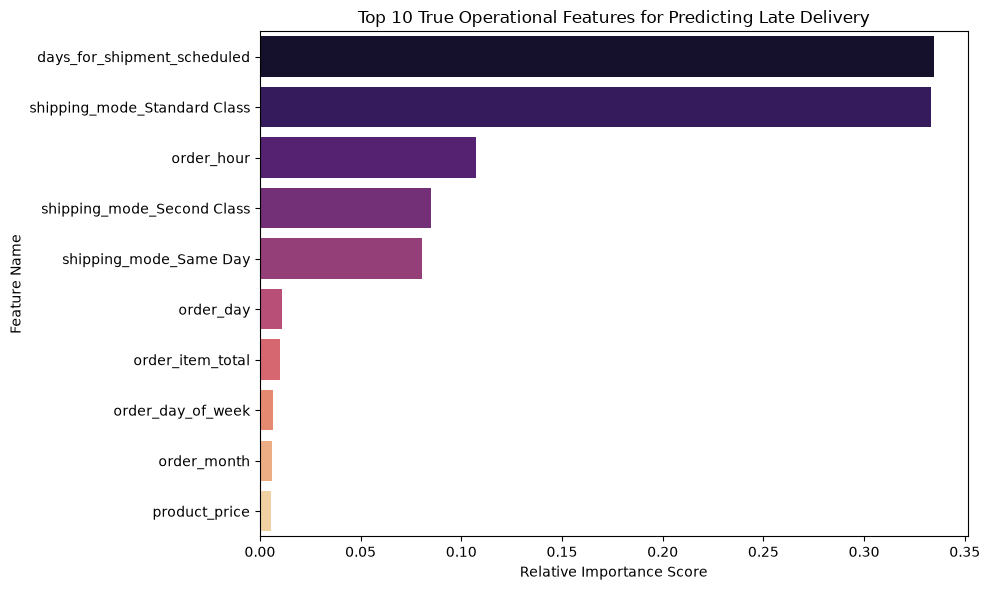

In [15]:
importances_p = predictive_model.feature_importances_
feature_names_p = X_predictive.columns

indices_p = np.argsort(importances_p)[::-1][:10]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_p[indices_p], y=feature_names_p[indices_p], palette='magma')
plt.title('Top 10 True Operational Features for Predicting Late Delivery')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [16]:
import pickle
import os

os.makedirs('models', exist_ok=True)

model_artifacts = {
    'model': predictive_model,
    'features': list(X_predictive.columns)
}

model_path = os.path.join('models', 'late_delivery_rf_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model_artifacts, f)
    
print(f"Leak-free predictive model and features securely exported to: {model_path}")

Leak-free predictive model and features securely exported to: models/late_delivery_rf_model.pkl
